In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gopalbhattrai/pascal-voc-2012-dataset")

print("Path to dataset files:", path)

c:\Users\Ohi\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 3.52G/3.52G [15:10<00:00, 4.15MB/s]  

Extracting files...


Path to dataset files: C:\Users\Ohi\.cache\kagglehub\datasets\gopalbhattrai\pascal-voc-2012-dataset\versions\1


In [4]:
import torch
print("Torch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.5.1+cu121
CUDA Available: True
GPU: NVIDIA GeForce GTX 1660 Ti with Max-Q Design


In [12]:
import os

root_path = r"C:\Users\Ohi\.cache\kagglehub\datasets\gopalbhattrai\pascal-voc-2012-dataset\versions\1"

for root, dirs, files in os.walk(root_path):
    if "JPEGImages" in dirs:
        jpeg_folder = os.path.join(root, "JPEGImages")
        print("Found JPEGImages at:", jpeg_folder)
        break

Found JPEGImages at: C:\Users\Ohi\.cache\kagglehub\datasets\gopalbhattrai\pascal-voc-2012-dataset\versions\1\VOC2012_test\VOC2012_test\JPEGImages


In [13]:
import cv2

image_files = os.listdir(jpeg_folder)
print("Total images:", len(image_files))

img_path = os.path.join(jpeg_folder, image_files[0])
print("Using:", img_path)

img = cv2.imread(img_path)

if img is None:
    raise ValueError("Image failed to load")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print("Image shape:", img.shape)

Total images: 16135
Using: C:\Users\Ohi\.cache\kagglehub\datasets\gopalbhattrai\pascal-voc-2012-dataset\versions\1\VOC2012_test\VOC2012_test\JPEGImages\2008_000001.jpg
Image shape: (500, 334, 3)


c:\Users\Ohi\AppData\Local\Programs\Python\Python310\lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


Total regions generated: 631
Unique proposals: 426


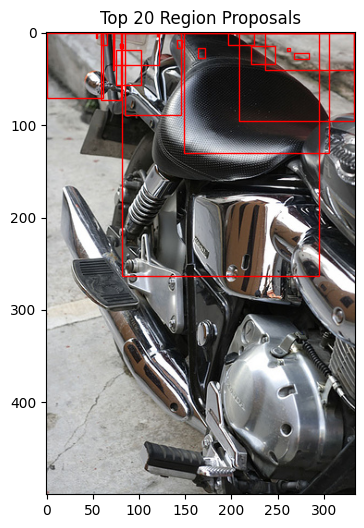

In [17]:
import selectivesearch

# Run selective search
img_lbl, regions = selectivesearch.selective_search(
    img, scale=500, sigma=0.9, min_size=10
)

print("Total regions generated:", len(regions))

proposals = []

for r in regions:
    if r['rect'] not in proposals:
        proposals.append(r['rect'])

print("Unique proposals:", len(proposals))

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, figsize=(8,6))
ax.imshow(img)

for x, y, w, h in proposals[:20]:
    rect = plt.Rectangle((x,y), w, h, fill=False, edgecolor='red', linewidth=1)
    ax.add_patch(rect)

plt.title("Top 20 Region Proposals")
plt.show()

In [15]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.vgg16(weights="IMAGENET1K_V1")
model.classifier = torch.nn.Sequential(*list(model.classifier.children())[:-1])
model = model.to(device)
model.eval()

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\Ohi/.cache\torch\hub\checkpoints\vgg16-397923af.pth
100%|██████████| 528M/528M [01:43<00:00, 5.35MB/s] 


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [19]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

features = []

for x, y, w, h in proposals[:50]:
    roi = img[y:y+h, x:x+w]
    if roi.size == 0:
        continue

    roi_tensor = transform(roi).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = model(roi_tensor)
    features.append(feat.cpu())

In [20]:
from sklearn.svm import LinearSVC
import numpy as np

X = torch.cat(features).numpy()
y = np.random.randint(0, 2, size=len(X))  # placeholder labels

svm = LinearSVC()
svm.fit(X, y)

c:\Users\Ohi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [21]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2-x1) * max(0, y2-y1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    union = area1 + area2 - inter
    return inter / union if union != 0 else 0

In [22]:
bbox_regressor = torch.nn.Linear(4096, 4).to(device)
criterion = torch.nn.SmoothL1Loss()

In [24]:
from torchvision.ops import nms

boxes = torch.tensor([[10,10,100,100],[15,15,105,105]], dtype=torch.float32)
scores = torch.tensor([0.9,0.8])

keep = nms(boxes, scores, 0.5)
print(keep)

tensor([0])


In [25]:
faster_model = models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
faster_model = faster_model.to(device)
faster_model.eval()

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\Ohi/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:41<00:00, 4.05MB/s] 


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [26]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.vgg16(weights="IMAGENET1K_V1")

# Remove final classification layer (keep 4096 features)
model.classifier = torch.nn.Sequential(*list(model.classifier.children())[:-1])

model = model.to(device)
model.eval()

print("Model loaded")

Model loaded


In [27]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [28]:
features = []
valid_proposals = []

for (x, y, w, h) in proposals[:200]:   # limit for speed
    roi = img[y:y+h, x:x+w]

    if roi.size == 0:
        continue

    roi_tensor = transform(roi).unsqueeze(0).to(device)

    with torch.no_grad():
        feature = model(roi_tensor)

    features.append(feature.cpu())
    valid_proposals.append((x, y, w, h))

print("Extracted features:", len(features))

Extracted features: 190


In [29]:
import xml.etree.ElementTree as ET

def get_ground_truth(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    boxes = []
    labels = []

    for obj in root.findall("object"):
        label = obj.find("name").text
        bbox = obj.find("bndbox")

        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(label)

    return boxes, labels

In [30]:
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter = max(0, xB - xA) * max(0, yB - yA)

    boxAArea = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    boxBArea = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])

    union = boxAArea + boxBArea - inter

    return inter / union if union > 0 else 0

In [37]:
import xml.etree.ElementTree as ET
import os

def get_ground_truth(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    boxes = []
    labels = []

    for obj in root.findall("object"):
        label = obj.find("name").text
        bbox = obj.find("bndbox")

        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(label)

    return boxes, labels

In [38]:
annotation_folder = jpeg_folder.replace("JPEGImages", "Annotations")

print("Annotation folder:", annotation_folder)
print("Exists:", os.path.exists(annotation_folder))

Annotation folder: C:\Users\Ohi\.cache\kagglehub\datasets\gopalbhattrai\pascal-voc-2012-dataset\versions\1\VOC2012_test\VOC2012_test\Annotations
Exists: True


In [40]:
import os

root_path = r"C:\Users\Ohi\.cache\kagglehub\datasets\gopalbhattrai\pascal-voc-2012-dataset\versions\1"

for root, dirs, files in os.walk(root_path):
    if "VOC2012_train_val" in root and "JPEGImages" in dirs:
        jpeg_folder = os.path.join(root, "JPEGImages")
        print("Train JPEG folder:", jpeg_folder)
        break

Train JPEG folder: C:\Users\Ohi\.cache\kagglehub\datasets\gopalbhattrai\pascal-voc-2012-dataset\versions\1\VOC2012_train_val\VOC2012_train_val\JPEGImages


In [41]:
image_files = os.listdir(jpeg_folder)
img_path = os.path.join(jpeg_folder, image_files[0])

import cv2
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Loaded:", img_path)

Loaded: C:\Users\Ohi\.cache\kagglehub\datasets\gopalbhattrai\pascal-voc-2012-dataset\versions\1\VOC2012_train_val\VOC2012_train_val\JPEGImages\2007_000027.jpg


In [42]:
annotation_folder = jpeg_folder.replace("JPEGImages", "Annotations")

xml_file = image_files[0].replace(".jpg", ".xml")
xml_path = os.path.join(annotation_folder, xml_file)

print("XML exists:", os.path.exists(xml_path))

gt_boxes, gt_labels = get_ground_truth(xml_path)

print("GT Boxes:", gt_boxes)
print("Labels:", gt_labels)

XML exists: True
GT Boxes: [[174, 101, 349, 351]]
Labels: ['person']


In [43]:
xml_file = image_files[0].replace(".jpg", ".xml")
xml_path = os.path.join(annotation_folder, xml_file)

print("XML path:", xml_path)
print("Exists:", os.path.exists(xml_path))

gt_boxes, gt_labels = get_ground_truth(xml_path)

print("Ground Truth Boxes:", gt_boxes)
print("Labels:", gt_labels)

XML path: C:\Users\Ohi\.cache\kagglehub\datasets\gopalbhattrai\pascal-voc-2012-dataset\versions\1\VOC2012_train_val\VOC2012_train_val\Annotations\2007_000027.xml
Exists: True
Ground Truth Boxes: [[174, 101, 349, 351]]
Labels: ['person']


In [35]:
import torchvision

faster_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
faster_model = faster_model.to(device)
faster_model.eval()

transform_frcnn = transforms.Compose([transforms.ToTensor()])
input_tensor = transform_frcnn(img).to(device)

with torch.no_grad():
    output = faster_model([input_tensor])

print("Faster R-CNN detections:", len(output[0]["boxes"]))

Faster R-CNN detections: 18
